# Per-Series Importance with Exogenous Features

This notebook demonstrates a powerful use case for per-series feature importance: **detecting heterogeneous effects of exogenous features across different time series**.

## The Problem

In multi-series forecasting, exogenous features (like temperature, promotions, or holidays) often have different effects on different series:
- Temperature might strongly affect ice cream sales in urban areas but not rural hardware stores
- Holiday flags might boost tourism in rural areas but have little effect on urban commuter shops

**Global feature importance analysis masks these heterogeneous effects**, showing only an "average" importance that may not reflect any individual series accurately.

## The Solution

Using `explain_per_series()`, we can compute feature importance separately for each series, revealing which exogenous features truly matter for each specific time series.

In [32]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from skforecast.recursive import ForecasterRecursiveMultiSeries
from skforecast.model_selection import bayesian_search_forecaster_multiseries, TimeSeriesFold

from xeries import (
    ConditionalPermutationImportance,
    SkforecastAdapter,
    plot_importance_bar,
    plot_importance_heatmap,
    plot_importance_per_series,
)

sns.set_theme(style='whitegrid')
print('Imports loaded.')

Imports loaded.


## 1. Generate Synthetic Data with Heterogeneous Exogenous Effects

We create 6 stores across 2 regions with **daily** sales data. The key insight is that **different exogenous features affect different regions**:

### Data Generation Logic

**Target Variable (Sales)**:
```
sales[t] = base_level + AR_effect + weekly_seasonality + trend + exogenous_effects + noise
```

Where:
- `base_level`: Different baseline for each store (100, 140, 180)
- `AR_effect`: 0.3 × sales[t-1] (autoregressive component)
- `weekly_seasonality`: 10 × sin(2π × t / 7) - captures weekly shopping patterns
- `trend`: Linear growth from 0 to 10 over the period
- `noise`: Random normal with σ=3

**Exogenous Feature Effects**:

| Feature | Formula | Urban Stores | Rural Stores |
|---------|---------|--------------|--------------|
| `temperature` | 15 + 12×sin(2π×t/365) + climate_offset + store_variation + noise | **+0.8 × (temp - 15)** | 0 (no effect) |
| `holiday_flag` | ~15% of days randomly | 0 (no effect) | **+25 per holiday** |
| `promotion` | ~30% of days randomly | **+15 per promo day** | **+15 per promo day** |

This design ensures:
- **Urban stores**: Sales increase with warmer temperatures (e.g., ice cream, outdoor activities), urban stores are in warmer climates (+8°C offset), additional store variation: -2, 0, +2°C 
- **Rural stores**: Sales spike on holidays (e.g., tourism destinations, weekend getaways), rural stores are in cooler climates (-8°C offset), additional store variation: -2, 0, +2°C 
- **All stores**: Respond equally to promotions

Data shape: (10950, 7)
Series: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']

Region mapping:
  urban_001: urban
  urban_002: urban
  urban_003: urban
  rural_001: rural
  rural_002: rural
  rural_003: rural

Exogenous features: temperature, holiday_flag, promotion


,date,series_id,region,value,temperature,holiday_flag,promotion
0,2023-01-01,urban_001,urban,100.000000,22.490142,0.0,1.0
1,2023-01-02,urban_001,urban,93.783033,20.791767,0.0,0.0
2,2023-01-03,urban_001,urban,99.358064,23.356125,0.0,0.0
3,2023-01-04,urban_001,urban,108.171557,26.188526,0.0,1.0
4,2023-01-05,urban_001,urban,94.466204,21.123169,0.0,1.0
5,2023-01-06,urban_001,urban,73.531687,21.329167,1.0,0.0
6,2023-01-07,urban_001,urban,85.715610,26.974859,0.0,1.0
7,2023-01-08,urban_001,urban,84.969123,24.744801,1.0,0.0
8,2023-01-09,urban_001,urban,89.216891,21.238922,0.0,0.0
9,2023-01-10,urban_001,urban,97.020716,24.479386,0.0,0.0


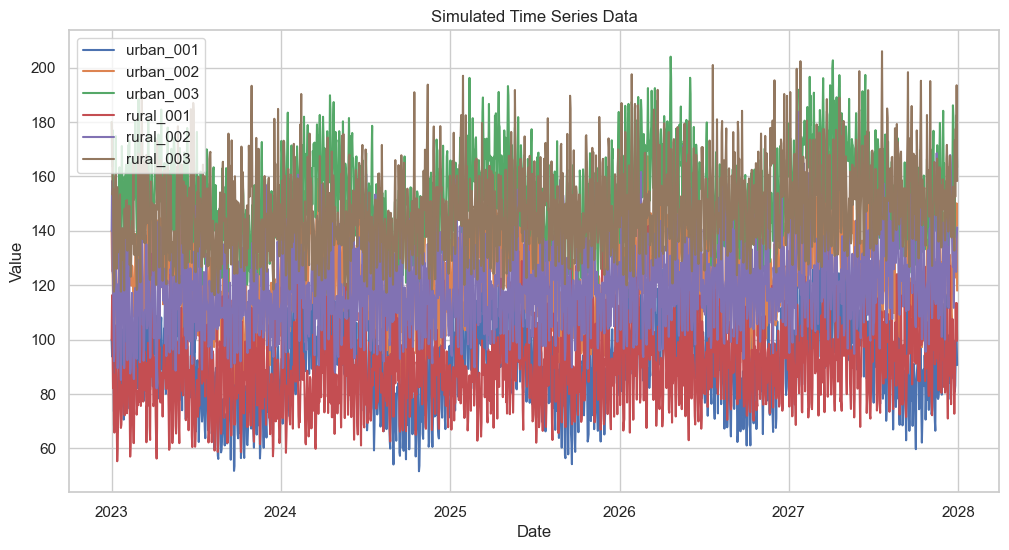

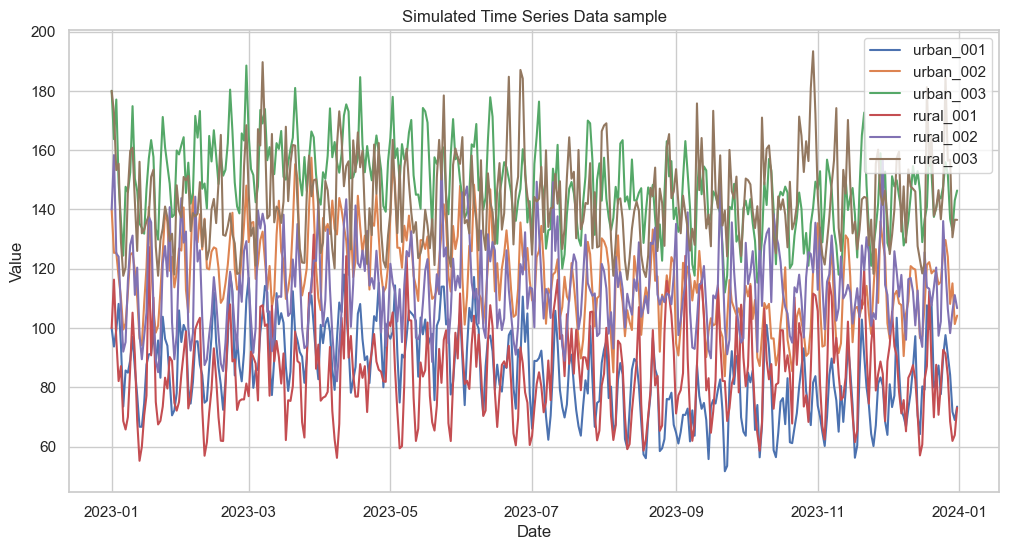

In [33]:
np.random.seed(42)

# =============================================================================
# Configuration
# =============================================================================
series_ids = ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']
regions = ['urban', 'urban', 'urban', 'rural', 'rural', 'rural']
n_days = 365 * 5  # Days per series (~5 years of daily data)

all_data = []

for i, (series_id, region) in enumerate(zip(series_ids, regions)):
    dates = pd.date_range(start='2023-01-01', periods=n_days, freq='D')
    
    # Seed each series differently for variation, but reproducibly
    np.random.seed(42 + i)
    
    # =========================================================================
    # EXOGENOUS FEATURES
    # =========================================================================
    
    # Temperature: yearly seasonal cycle with SERIES-SPECIFIC climate offset
    # Urban stores are in warmer climates (+8°C offset)
    # Rural stores are in cooler climates (-8°C offset)
    # Additional store variation: -2, 0, +2°C per store within region
    # This creates distinct per-series distributions for OOD analysis
    climate_offset = 8 if region == 'urban' else -8  # Urban warmer, rural cooler
    store_variation = (i % 3) * 2 - 2  # Per-store variation: -2, 0, +2
    temperature = (15 + climate_offset + store_variation + 
                   12 * np.sin(2 * np.pi * np.arange(n_days) / 365) + 
                   np.random.normal(0, 3, n_days))
    
    # Holiday flag: ~15% of days are holidays (binary feature)
    holiday_flag = (np.random.random(n_days) > 0.85).astype(float)
    
    # Promotion: ~30% of days have promotions (binary feature)
    promotion = (np.random.random(n_days) > 0.7).astype(float)
    
    # =========================================================================
    # TARGET VARIABLE COMPONENTS
    # =========================================================================
    
    # Base level: varies by store (100, 140, 180) to simulate different store sizes
    base = 100 + (i % 3) * 40
    
    # Trend: gradual linear growth over time (0 to 10)
    trend = np.linspace(0, 10, n_days)
    
    # Weekly seasonality: 7-day cycle capturing weekly shopping patterns
    # Formula: 10*sin(2π*t/7) - peaks mid-week, dips on weekends (or vice versa)
    weekly_pattern = 10 * np.sin(2 * np.pi * np.arange(n_days) / 7)
    
    # Initialize sales values
    values = np.zeros(n_days)
    values[0] = base
    
    # =========================================================================
    # GENERATE SALES WITH HETEROGENEOUS EXOGENOUS EFFECTS
    # =========================================================================
    for t in range(1, n_days):
        # AR(1) component: sales depend on previous day (coefficient = 0.3)
        ar_effect = 0.3 * values[t-1]
        
        # -----------------------------------------------------------------
        # KEY: Exogenous effects differ by region!
        # -----------------------------------------------------------------
        if region == 'urban':
            # URBAN stores: temperature-sensitive (e.g., ice cream, outdoor goods)
            # Effect: +0.8 units per degree above 15°C (or -0.8 below)
            temp_effect = 0.8 * (temperature[t] - 15)
            holiday_effect = 0.0  # Holidays have NO effect on urban stores
        else:
            # RURAL stores: holiday-sensitive (e.g., tourism, weekend destinations)
            # Effect: +25 units on holiday days
            temp_effect = 0.0  # Temperature has NO effect on rural stores
            holiday_effect = 25.0 * holiday_flag[t]
        
        # Promotion effect: same for ALL stores (+15 units on promo days)
        promo_effect = 15.0 * promotion[t]
        
        # Combine all components into daily sales
        values[t] = (
            base * 0.5 +           # Baseline contribution
            ar_effect +            # Autoregressive (momentum)
            weekly_pattern[t] +    # Weekly seasonality
            trend[t] +             # Long-term trend
            temp_effect +          # Temperature effect (URBAN ONLY)
            holiday_effect +       # Holiday effect (RURAL ONLY)
            promo_effect +         # Promotion effect (ALL stores)
            np.random.normal(0, 3) # Random noise
        )
    
    # Store this series' data
    df = pd.DataFrame({
        'date': dates,
        'series_id': series_id,
        'region': region,
        'value': values,           # Target: daily sales
        'temperature': temperature, # Exog: affects URBAN only
        'holiday_flag': holiday_flag, # Exog: affects RURAL only
        'promotion': promotion      # Exog: affects ALL stores
    })
    all_data.append(df)

# Combine all series into one DataFrame
data = pd.concat(all_data, ignore_index=True)

print(f"Data shape: {data.shape}")
print(f"Series: {data['series_id'].unique().tolist()}")
print(f"\nRegion mapping:")
for s, r in zip(series_ids, regions):
    print(f"  {s}: {r}")
print(f"\nExogenous features: temperature, holiday_flag, promotion")
display(data.head(10))
#plotting the series
plt.figure(figsize=(12, 6))
for series_id in series_ids:
    subset = data[data['series_id'] == series_id]
    plt.plot(subset['date'], subset['value'], label=series_id)
plt.title('Simulated Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

# plot 1 year for better visualization
plt.figure(figsize=(12, 6))
for series_id in series_ids:
    subset = data[data['series_id'] == series_id][:365]
    plt.plot(subset['date'], subset['value'], label=series_id)
plt.title('Simulated Time Series Data sample')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()



## 2. Prepare Multi-Series Inputs for skforecast

`skforecast` creates lagged features internally, so we prepare:
- `series_dict`: one target series per `series_id`
- `exog_dict`: aligned exogenous features per `series_id`

In [34]:
# Exogenous features used by skforecast
exog_features = ['temperature', 'holiday_flag', 'promotion']

# Build skforecast inputs as dictionaries keyed by series_id
series_dict = {}
exog_dict = {}

for sid in series_ids:
    subset = (
        data[data['series_id'] == sid]
        .sort_values('date')
        .set_index('date')
        .asfreq('D')
    )
    series_dict[sid] = subset['value'].rename(sid)
    exog_dict[sid] = subset[exog_features]

# Keep a simple mapping for readable output
series_mapping = {s: i for i, s in enumerate(series_ids)}
reverse_mapping = {v: k for k, v in series_mapping.items()}

print(f"Number of series: {len(series_dict)}")
print(f"Rows per series (example {series_ids[0]}): {len(series_dict[series_ids[0]])}")
print(f"Series index frequency: {series_dict[series_ids[0]].index.freq}")
print(f"Exogenous features: {exog_features}")
display(exog_dict[series_ids[0]].head())

Number of series: 6
Rows per series (example urban_001): 1825
Series index frequency: <Day>
Exogenous features: ['temperature', 'holiday_flag', 'promotion']


,temperature,holiday_flag,promotion
date,,,
2023-01-01,22.490142,0.0,1.0
2023-01-02,20.791767,0.0,0.0
2023-01-03,23.356125,0.0,0.0
2023-01-04,26.188526,0.0,1.0
2023-01-05,21.123169,0.0,1.0


## 3. Setup Output Directories

Create publication output directories for figures, tuning artifacts, tables, and metadata.

In [35]:
# Publication output directories
OUTPUT_ROOT = Path().resolve().parent / 'outputs'
FIGURE_DIR = OUTPUT_ROOT / 'figures'
TUNING_DIR = OUTPUT_ROOT / 'tuning'
TABLE_DIR = OUTPUT_ROOT / 'tables'
METADATA_DIR = OUTPUT_ROOT / 'metadata'

for d in [FIGURE_DIR, TUNING_DIR, TABLE_DIR, METADATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Output directories created under {OUTPUT_ROOT}')

Output directories created under C:\Workspace\Research\conditional_multi_series\outputs


## 4. Optuna Hyperparameter Tuning

Use Bayesian search to tune lag structure and LightGBM hyperparameters. Save tuning artifacts for reproducibility.

In [36]:
# Tuning configuration (publication profile)
RANDOM_SEED = 42
N_TRIALS = 120  # Use 200+ for camera-ready reruns

# Define search space
def search_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

# Base forecaster for search
forecaster_search = ForecasterRecursiveMultiSeries(
    regressor=LGBMRegressor(random_state=RANDOM_SEED, verbose=-1),
    lags=3,
    encoding='ordinal',
    transformer_series=StandardScaler(),
)

# Time-based validation split (last 28 days for validation)
first_series = list(series_dict.keys())[0]
series_length = len(series_dict[first_series])

# Cross-validation fold configuration
cv = TimeSeriesFold(
    initial_train_size=series_length - 28,
    steps=28,
    fixed_train_size=False,
    refit=False,
)

print(f'Running Bayesian search with {N_TRIALS} trials...')
print(f'Series length: {series_length}, validation size: 28 days')

search_results = bayesian_search_forecaster_multiseries(
    forecaster=forecaster_search,
    series=series_dict,
    exog=exog_dict,
    search_space=search_space,
    cv=cv,
    metric='mean_squared_error',
    n_trials=N_TRIALS,
    random_state=RANDOM_SEED,
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True,
)


# Extract best configuration (new API returns (results_df, best_trial))
trials_df, best_trial = search_results
best_lags = trials_df.loc[0, 'lags']
best_params = trials_df.loc[0, 'params']

print(f'\nBest lags: {best_lags}')
print(f'Best params: {best_params}')

# Save tuning artifacts
trials_df = search_results[0]
trials_df.to_csv(TUNING_DIR / '01_optuna_trials.csv', index=False)
print(f'Saved trials to {TUNING_DIR / "01_optuna_trials.csv"}')

best_config = {
    'best_lags': best_lags.tolist() if hasattr(best_lags, 'tolist') else (best_lags if isinstance(best_lags, list) else list(range(1, best_lags + 1))),
    'best_params': best_params,
    'n_trials': N_TRIALS,
    'random_seed': RANDOM_SEED,
    'metric': 'mean_squared_error',
}
with open(METADATA_DIR / '01_best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print(f'Saved best config to {METADATA_DIR / "01_best_config.json"}')

# Create LaTeX table for best parameters
params_for_latex = {
    'Parameter': [],
    'Value': [],
}
params_for_latex['Parameter'].append('Lags')
params_for_latex['Value'].append(str(best_config['best_lags']))
for k, v in best_params.items():
    params_for_latex['Parameter'].append(k.replace('_', '\\_'))
    params_for_latex['Value'].append(str(v))
params_for_latex['Parameter'].extend(['N Trials', 'Random Seed', 'Metric'])
params_for_latex['Value'].extend([str(N_TRIALS), str(RANDOM_SEED), 'MSE'])

params_df = pd.DataFrame(params_for_latex)
latex_params = params_df.to_latex(index=False, escape=False, column_format='ll',
    caption='Optimal hyperparameters from Bayesian search.',
    label='tab:01_best_params')
with open(TABLE_DIR / '01_best_params.tex', 'w') as f:
    f.write(latex_params)
print(f'Saved LaTeX params table to {TABLE_DIR / "01_best_params.tex"}')

Running Bayesian search with 120 trials...
Series length: 1825, validation size: 28 days


C:\Users\MKU4CLJ\AppData\Local\Temp\ipykernel_35820\3172573279.py:18: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster_search = ForecasterRecursiveMultiSeries(


  0%|          | 0/120 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1 2 3] 
  Parameters: {'n_estimators': 459, 'learning_rate': 0.0929474362539201, 'num_leaves': 21, 'max_depth': 8, 'min_child_samples': 29, 'reg_alpha': 2.7294040169384375, 'reg_lambda': 0.0001463213583757832}
  Backtesting metric: 122.21690692921756
  Levels: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']


Best lags: [1 2 3]
Best params: {'n_estimators': 459, 'learning_rate': 0.0929474362539201, 'num_leaves': 21, 'max_depth': 8, 'min_child_samples': 29, 'reg_alpha': 2.7294040169384375, 'reg_lambda': 0.0001463213583757832}
Saved trials to C:\Workspace\Research\conditional_multi_series\outputs\tuning\01_optuna_trials.csv
Saved best config to C:\Workspace\Research\conditional_multi_series\outputs\metadata\01_best_config.json
Saved LaTeX params table to C:\Workspace\Research\conditional_multi_series\outputs\tables\01_best_params.tex


## 5. Refit Final Model with Best Parameters

Refit the forecaster using the optimal lags and hyperparameters from Optuna search.

In [37]:
# Use best parameters from Optuna search
estimator = LGBMRegressor(
    **best_params,
    random_state=RANDOM_SEED,
    verbose=-1,
)

forecaster = ForecasterRecursiveMultiSeries(
    regressor=estimator,
    lags=best_lags,
    encoding='ordinal',
    transformer_series=StandardScaler(),
)

print(f'Refitting forecaster with best_lags={best_lags}...')
forecaster.fit(series=series_dict, exog=exog_dict)
print('Forecaster fitted with optimized configuration.')

# Build the supervised matrix generated by skforecast
X_train_sk, y_train_sk = forecaster.create_train_X_y(
    series=series_dict,
    exog=exog_dict,
 )

# Identify the series identifier column in the generated design matrix
series_col = next(
    (c for c in X_train_sk.columns if 'level' in c.lower() or 'series' in c.lower()),
    None,
 )
if series_col is None:
    raise ValueError('Could not detect the series identifier column in X_train_sk.')

explain_features = [c for c in X_train_sk.columns if c != series_col]

print(f"Supervised matrix shape: {X_train_sk.shape}")
print(f"Target shape: {getattr(y_train_sk, 'shape', len(y_train_sk))}")
print(f"Series column for per-series explainability: {series_col}")
print(f"Number of explainable features: {len(explain_features)}")
display(X_train_sk.head())


# id to string mapping
name_to_id = {name: i for i, name in enumerate(forecaster.series_names_in_)}
id_to_name = {i: name for name, i in name_to_id.items()}


Refitting forecaster with best_lags=[1 2 3]...


C:\Users\MKU4CLJ\AppData\Local\Temp\ipykernel_35820\7595647.py:8: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster = ForecasterRecursiveMultiSeries(


Forecaster fitted with optimized configuration.
Supervised matrix shape: (10932, 7)
Target shape: (10932,)
Series column for per-series explainability: _level_skforecast
Number of explainable features: 6


,lag_1,lag_2,lag_3,_level_skforecast,temperature,holiday_flag,promotion
date,,,,,,,
2023-01-04,0.494351,0.135775,0.535639,3,26.188526,0.0,1.0
2023-01-05,1.061219,0.494351,0.135775,3,21.123169,0.0,1.0
2023-01-06,0.179716,1.061219,0.494351,3,21.329167,1.0,0.0
2023-01-07,-1.166755,0.179716,1.061219,3,26.974859,0.0,1.0
2023-01-08,-0.383107,-1.166755,0.179716,3,24.744801,1.0,0.0


## 6. Compute Global Feature Importance

We now compute conditional permutation importance on the supervised matrix generated by `skforecast`.
This keeps forecasting and explainability consistent with the same global model representation.

In [38]:
# Create xeries adapter for the trained skforecast model
adapter = SkforecastAdapter(
    forecaster=forecaster,
    series=series_dict,
    exog=exog_dict,
 )

explainer = ConditionalPermutationImportance(
    model=adapter,
    metric=mean_squared_error,
    n_repeats=20,  # Publication level (increased from 5)
    random_state=42,
 )

# Global conditional permutation importance
global_result = explainer.explain(
    X=X_train_sk,
    y=y_train_sk,
    features=explain_features,
 )

importance_df = global_result.to_dataframe().sort_values('importance', ascending=False)

print('=== GLOBAL Conditional Feature Importance ===')
print('(Aggregated across all series in the skforecast design matrix)')
display(importance_df)

c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== GLOBAL Conditional Feature Importance ===
(Aggregated across all series in the skforecast design matrix)


,feature,importance,std
0,lag_1,0.440576,0.006664
5,promotion,0.409573,0.004674
4,holiday_flag,0.320109,0.006404
3,temperature,0.193172,0.003416
2,lag_3,0.093998,0.001933
1,lag_2,0.057305,0.000956


In [39]:
# Keep only exogenous features for a focused interpretation table
exog_importance_df = importance_df[importance_df['feature'].isin(exog_features)].copy()

print('=== GLOBAL Exogenous Feature Importance ===')
display(exog_importance_df.sort_values('importance', ascending=False))

=== GLOBAL Exogenous Feature Importance ===


,feature,importance,std
5,promotion,0.409573,0.004674
4,holiday_flag,0.320109,0.006404
3,temperature,0.193172,0.003416


Saved global importance figures to C:\Workspace\Research\conditional_multi_series\outputs\figures


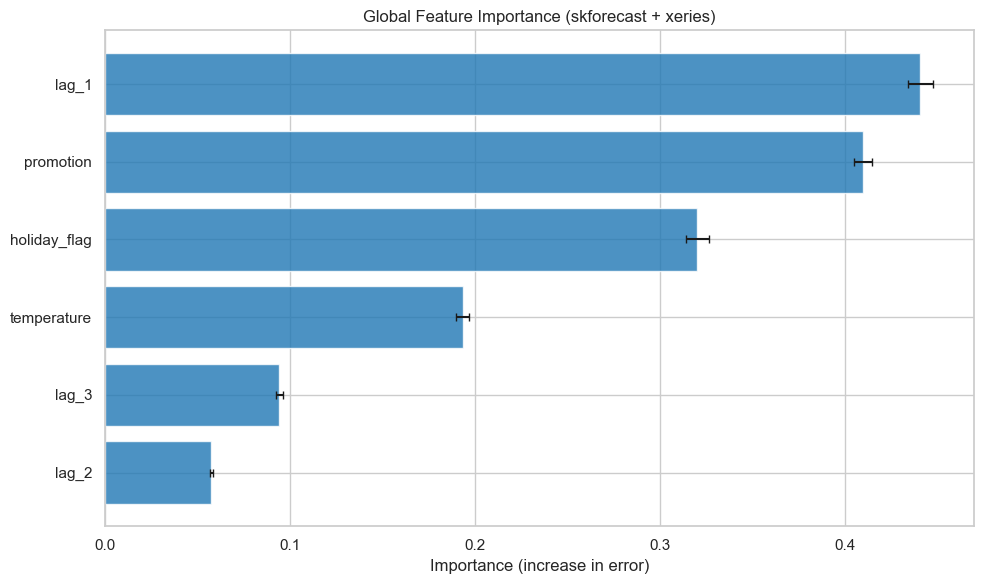

Saved importance tables to C:\Workspace\Research\conditional_multi_series\outputs\tables


In [40]:
# Visualize global importance
fig, ax = plot_importance_bar(
    global_result,
    max_features=12,
    title='Global Feature Importance (skforecast + xeries)',
)
fig.savefig(FIGURE_DIR / '01_global_importance.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_global_importance.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved global importance figures to {FIGURE_DIR}')
plt.show()

# Export CSV tables
importance_df.to_csv(TABLE_DIR / '01_global_importance.csv', index=False)

# Export LaTeX table
latex_importance = importance_df.to_latex(index=False, float_format='%.4f',
    caption='Global feature importance scores.',
    label='tab:01_global_importance')
with open(TABLE_DIR / '01_global_importance.tex', 'w') as f:
    f.write(latex_importance)
print(f'Saved importance tables to {TABLE_DIR}')

### Observation

The global importance shows moderate values for both `temperature` and `holiday_flag`. But this is misleading!
- `temperature` only affects urban stores
- `holiday_flag` only affects rural stores

The global view averages out these effects, hiding the true story.

## 7. Compute Per-Series Feature Importance

Now let's use `explain_per_series()` to reveal the **true heterogeneous effects**.

In [41]:
# Compute per-series importance using the detected series column
per_series_results_raw = explainer.explain_per_series(
    X=X_train_sk,
    y=y_train_sk,
    series_col=series_col,
    features=explain_features,
 )

# Normalize keys to readable series names.
# skforecast ordinal encoding is typically alphabetical by series name.
alphabetical_series_ids = sorted(series_ids)
per_series_results = {}

for key, value in per_series_results_raw.items():
    readable_key = None

    # Already a string label
    if key in series_ids:
        readable_key = key
    else:
        # Try integer-like code mapped to alphabetical order
        try:
            key_int = int(key)
            if 0 <= key_int < len(alphabetical_series_ids):
                readable_key = alphabetical_series_ids[key_int]
        except (TypeError, ValueError):
            readable_key = None

    if readable_key is None:
        readable_key = str(key)

    per_series_results[readable_key] = value

print(f"Computed importance for {len(per_series_results)} series")
print(f"Mapped series keys: {list(per_series_results.keys())}")

c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X 

Computed importance for 6 series
Mapped series keys: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']


c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X 

In [42]:
# Display results for each series
for series_id, result in per_series_results.items():
    region = 'URBAN' if 'urban' in series_id else 'RURAL'
    print(f"\n=== {series_id} ({region}) ===")
    df = result.to_dataframe()
    # Highlight exogenous features
    for _, row in df.iterrows():
        marker = " <-- EXOG" if row['feature'] in exog_features else ""
        print(f"  {row['feature']:15} {row['importance']:8.4f}{marker}")


=== urban_001 (URBAN) ===
  lag_1             0.7807
  promotion         0.4153 <-- EXOG
  temperature       0.3879 <-- EXOG
  lag_3             0.1162
  lag_2             0.0701
  holiday_flag      0.0051 <-- EXOG

=== urban_002 (URBAN) ===
  lag_1             0.7847
  promotion         0.4148 <-- EXOG
  temperature       0.4093 <-- EXOG
  lag_3             0.1261
  lag_2             0.0728
  holiday_flag      0.0022 <-- EXOG

=== urban_003 (URBAN) ===
  lag_1             0.7810
  promotion         0.4206 <-- EXOG
  temperature       0.4143 <-- EXOG
  lag_3             0.1321
  lag_2             0.0712
  holiday_flag      0.0032 <-- EXOG

=== rural_001 (RURAL) ===
  holiday_flag      0.6552 <-- EXOG
  lag_1             0.5593
  promotion         0.4193 <-- EXOG
  lag_3             0.1189
  lag_2             0.0745
  temperature       0.0305 <-- EXOG

=== rural_002 (RURAL) ===
  holiday_flag      0.6408 <-- EXOG
  lag_1             0.5252
  promotion         0.3978 <-- EXOG
  lag_3   

## 8. Visualize Per-Series Importance

Saved per-series importance figures to C:\Workspace\Research\conditional_multi_series\outputs\figures


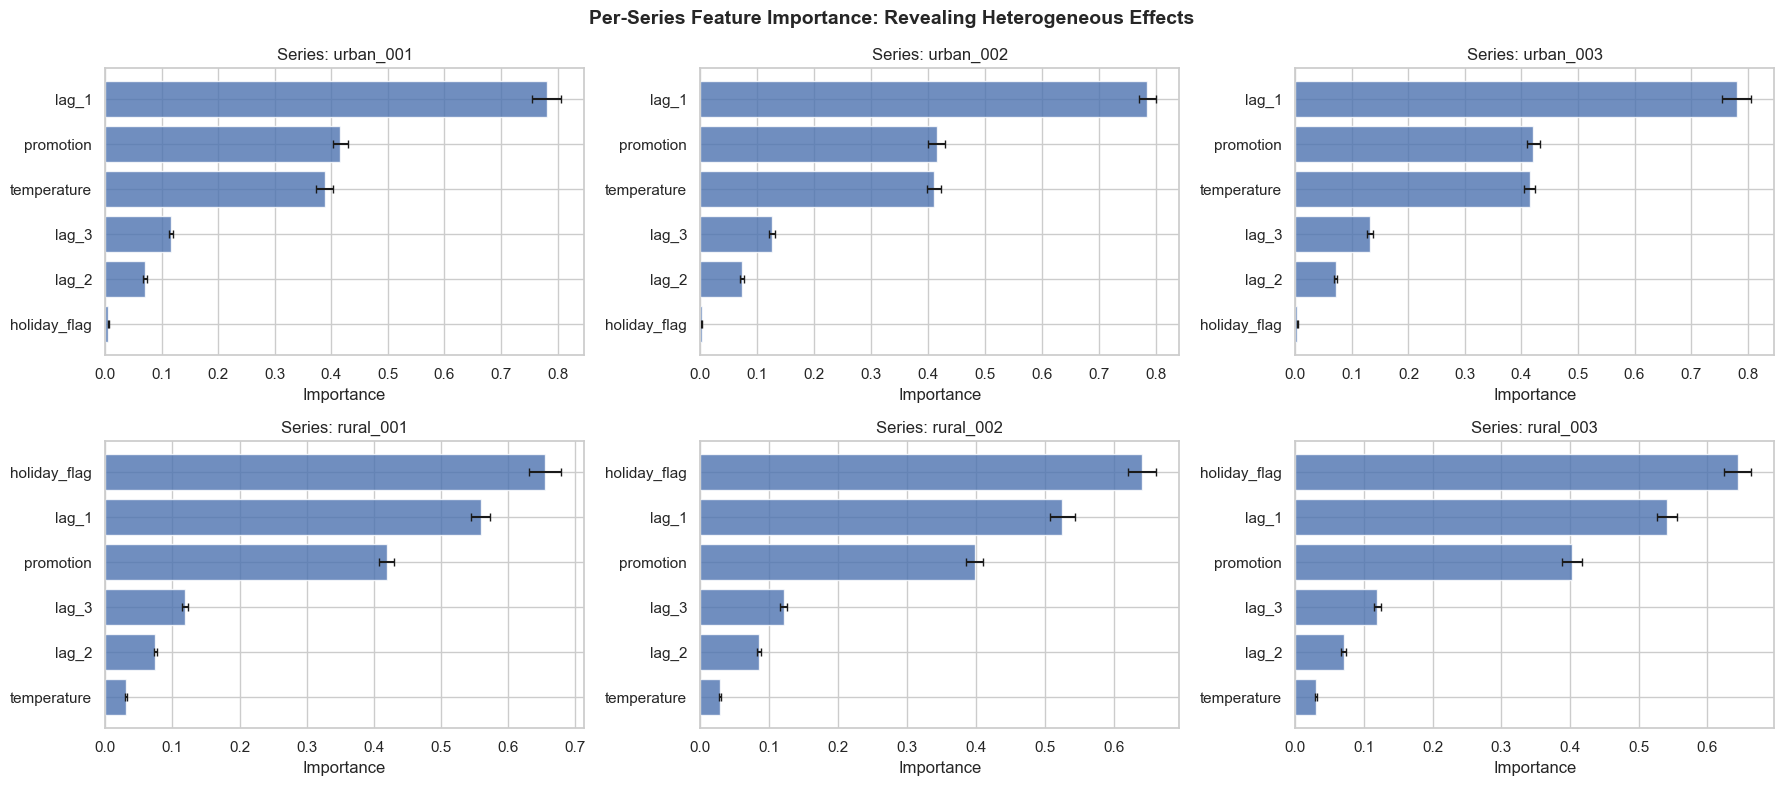

Saved per-series importance tables to C:\Workspace\Research\conditional_multi_series\outputs\tables


In [43]:
# Grid of bar charts for all series
fig, axes = plot_importance_per_series(
    per_series_results,
    max_features=6,
    ncols=3,
    title="Per-Series Feature Importance: Revealing Heterogeneous Effects"
)
fig.savefig(FIGURE_DIR / '01_per_series_importance.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_per_series_importance.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved per-series importance figures to {FIGURE_DIR}')
plt.show()

# Export per-series importance table
per_series_df = pd.concat([
    r.to_dataframe().assign(series=name)
    for name, r in per_series_results.items()
])
per_series_df.to_csv(TABLE_DIR / '01_per_series_importance.csv', index=False)

# Export LaTeX table
latex_per_series = per_series_df.to_latex(index=False, float_format='%.4f',
    caption='Per-series feature importance scores.',
    label='tab:01_per_series_importance')
with open(TABLE_DIR / '01_per_series_importance.tex', 'w') as f:
    f.write(latex_per_series)
print(f'Saved per-series importance tables to {TABLE_DIR}')

Saved heatmap to C:\Workspace\Research\conditional_multi_series\outputs\figures


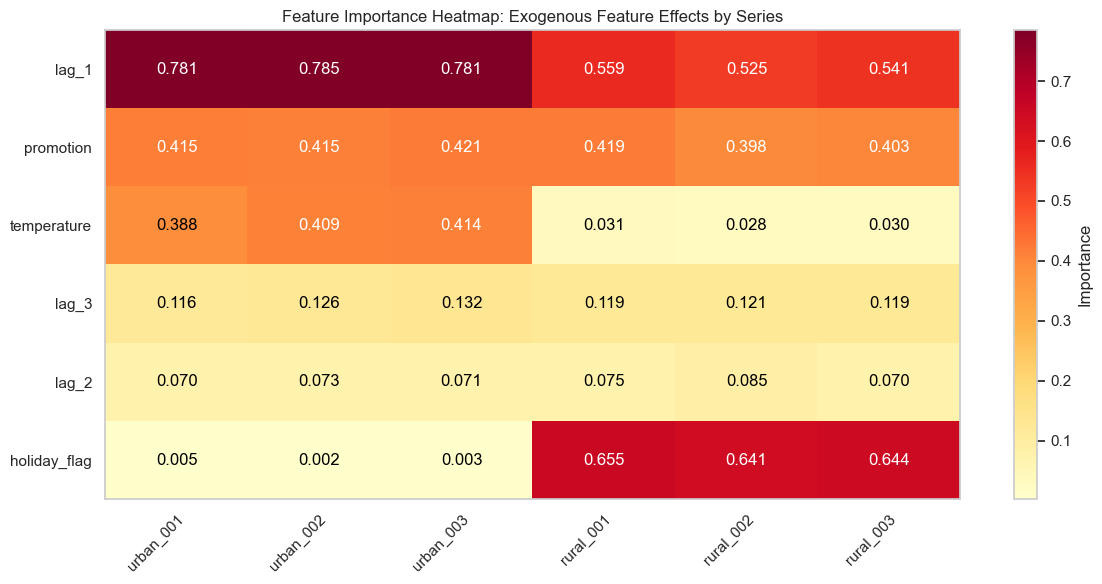

In [44]:
# Heatmap comparison across all series
fig, ax = plot_importance_heatmap(
    per_series_results,
    features=explain_features,
    figsize=(12, 6),
    title="Feature Importance Heatmap: Exogenous Feature Effects by Series"
)
fig.savefig(FIGURE_DIR / '01_importance_heatmap.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_importance_heatmap.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved heatmap to {FIGURE_DIR}')
plt.show()

## 9. Compare Urban vs Rural Groups

Let's aggregate by region to clearly see the pattern.

In [45]:
# Separate results by region
urban_results = {k: v for k, v in per_series_results.items() if 'urban' in k}
rural_results = {k: v for k, v in per_series_results.items() if 'rural' in k}

# Aggregate importance by region
def aggregate_importance(results_dict):
    all_importances = {}
    for _, result in results_dict.items():
        for feat, imp in zip(result.feature_names, result.importances):
            all_importances.setdefault(feat, []).append(float(imp))
    return {feat: float(np.mean(vals)) for feat, vals in all_importances.items()}

urban_avg_all = aggregate_importance(urban_results)
rural_avg_all = aggregate_importance(rural_results)

# Focus comparison on exogenous features only
urban_avg = {f: urban_avg_all.get(f, 0.0) for f in exog_features}
rural_avg = {f: rural_avg_all.get(f, 0.0) for f in exog_features}
global_avg = {
    f: float(global_result.importances[global_result.feature_names.index(f)])
    for f in exog_features
    if f in global_result.feature_names
}

comparison_df = pd.DataFrame({
    'Feature': exog_features,
    'Urban (avg)': [urban_avg.get(f, 0.0) for f in exog_features],
    'Rural (avg)': [rural_avg.get(f, 0.0) for f in exog_features],
    'Global': [global_avg.get(f, 0.0) for f in exog_features],
}).set_index('Feature')

print('=== Exogenous Feature Importance Comparison ===')
print(comparison_df.round(4).to_string())

=== Exogenous Feature Importance Comparison ===
              Urban (avg)  Rural (avg)  Global
Feature                                       
temperature        0.4038       0.0295  0.1932
holiday_flag       0.0035       0.6468  0.3201
promotion          0.4169       0.4067  0.4096


Saved Urban vs Rural comparison to C:\Workspace\Research\conditional_multi_series\outputs\figures


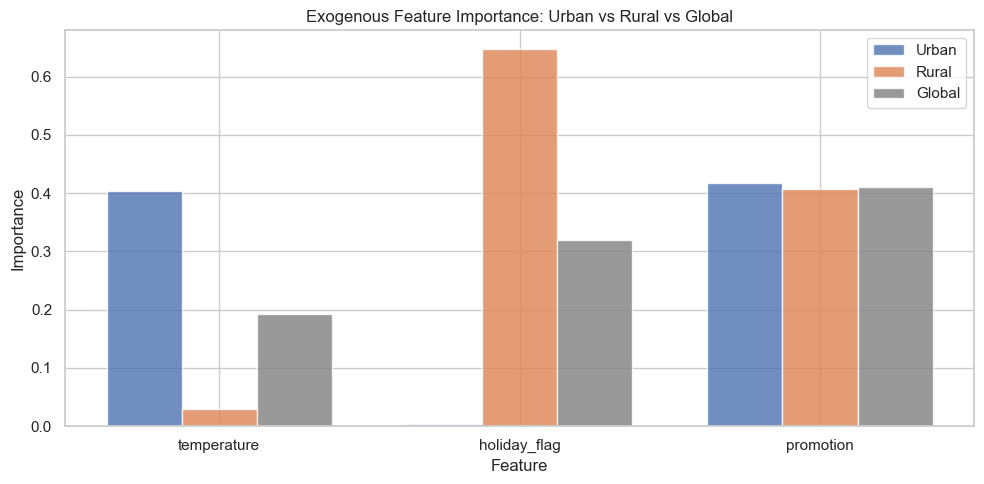

In [46]:
# Visualize exogenous feature comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x = np.arange(len(exog_features))
width = 0.25

ax.bar(x - width, comparison_df['Urban (avg)'], width, label='Urban', alpha=0.8)
ax.bar(x, comparison_df['Rural (avg)'], width, label='Rural', alpha=0.8)
ax.bar(x + width, comparison_df['Global'], width, label='Global', alpha=0.8, color='gray')

ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Exogenous Feature Importance: Urban vs Rural vs Global')
ax.set_xticks(x)
ax.set_xticklabels(exog_features)
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_urban_vs_rural_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_urban_vs_rural_comparison.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved Urban vs Rural comparison to {FIGURE_DIR}')
plt.show()

## 10. Key Insights

### What Per-Series Analysis Reveals:

| Feature | True Effect | Global Importance | Per-Series Finding |
|---------|-------------|-------------------|--------------------|
| `temperature` | Urban only | Moderate | High for urban, ~0 for rural |
| `holiday_flag` | Rural only | Moderate | High for rural, ~0 for urban |
| `promotion` | All series | Moderate | Consistent across all series |

### Why This Matters:

1. **Better Feature Understanding**: Global importance would suggest both `temperature` and `holiday_flag` are moderately important everywhere. Per-series analysis reveals the true, actionable insight.

2. **Targeted Interventions**: If you're planning a marketing campaign:
   - For urban stores: Focus on temperature-based promotions (e.g., hot weather discounts)
   - For rural stores: Plan around holidays and tourism seasons

3. **Model Debugging**: If predictions are poor for specific series, per-series importance helps identify which features the model is (incorrectly) relying on.

4. **Feature Engineering**: Knowing that `temperature` only matters for urban stores, you might create interaction features like `temperature * is_urban`.

In [47]:
# Final summary table
print("\n" + "="*60)
print("SUMMARY: Heterogeneous Exogenous Feature Effects")
print("="*60)

def dominant_group(feature_name: str) -> str:
    u = urban_avg.get(feature_name, 0.0)
    r = rural_avg.get(feature_name, 0.0)
    if abs(u - r) < 1e-9:
        return "balanced"
    return "urban" if u > r else "rural"

print("\nTemperature Effect:")
print(f"  Urban stores:  {urban_avg.get('temperature', 0):.4f}")
print(f"  Rural stores:  {rural_avg.get('temperature', 0):.4f}")
print(f"  Dominant group: {dominant_group('temperature').upper()}")

print("\nHoliday Flag Effect:")
print(f"  Urban stores:  {urban_avg.get('holiday_flag', 0):.4f}")
print(f"  Rural stores:  {rural_avg.get('holiday_flag', 0):.4f}")
print(f"  Dominant group: {dominant_group('holiday_flag').upper()}")

print("\nPromotion Effect:")
print(f"  Urban stores:  {urban_avg.get('promotion', 0):.4f}")
print(f"  Rural stores:  {rural_avg.get('promotion', 0):.4f}")
print(f"  Dominant group: {dominant_group('promotion').upper()}")

print("\n" + "="*60)


SUMMARY: Heterogeneous Exogenous Feature Effects

Temperature Effect:
  Urban stores:  0.4038
  Rural stores:  0.0295
  Dominant group: URBAN

Holiday Flag Effect:
  Urban stores:  0.0035
  Rural stores:  0.6468
  Dominant group: RURAL

Promotion Effect:
  Urban stores:  0.4169
  Rural stores:  0.4067
  Dominant group: URBAN



## 11. Out-of-Distribution Analysis

This section validates the methodological choice of **conditional permutation** over global permutation.
We demonstrate that:
- **Global permutation** creates unrealistic, out-of-distribution data by destroying series-specific patterns
- **Conditional permutation** preserves the original data distribution within each series

We measure distribution distances using Wasserstein distance and Kolmogorov-Smirnov statistics.

In [48]:
from scipy.stats import wasserstein_distance, ks_2samp

# Identify exogenous features (non-lag features)
exog_features = [f for f in explain_features if not f.startswith('lag_')]
print(f'Exogenous features for OOD analysis: {exog_features}')

# Create permuted datasets
np.random.seed(RANDOM_SEED)

X_global_perm = X_train_sk.copy()
X_cond_perm = X_train_sk.copy()

for feat in exog_features:
    # Global permutation: shuffle across ALL rows (ignores series boundaries)
    X_global_perm[feat] = np.random.permutation(X_train_sk[feat].values)
    
    # Conditional permutation: shuffle WITHIN each series group
    for series_id in X_train_sk[series_col].unique():
        mask = X_train_sk[series_col] == series_id
        X_cond_perm.loc[mask, feat] = np.random.permutation(
            X_train_sk.loc[mask, feat].values
        )

print(f'Created permuted datasets with shape: {X_global_perm.shape}')

Exogenous features for OOD analysis: ['temperature', 'holiday_flag', 'promotion']
Created permuted datasets with shape: (10932, 7)


In [49]:
# Compute distribution distances per series and feature
distance_records = []

for series_id in X_train_sk[series_col].unique():
    mask = X_train_sk[series_col] == series_id
    
    for feat in exog_features:
        orig_vals = X_train_sk.loc[mask, feat].values
        global_vals = X_global_perm.loc[mask, feat].values
        cond_vals = X_cond_perm.loc[mask, feat].values
        
        # Wasserstein distance (Earth Mover's Distance)
        wd_global = wasserstein_distance(orig_vals, global_vals)
        wd_cond = wasserstein_distance(orig_vals, cond_vals)
        
        # KS statistic
        ks_global, _ = ks_2samp(orig_vals, global_vals)
        ks_cond, _ = ks_2samp(orig_vals, cond_vals)
        
        distance_records.append({
            'series': sorted(series_ids)[series_id] if isinstance(series_id, int) else series_id,
            'feature': feat,
            'wasserstein_global': wd_global,
            'wasserstein_conditional': wd_cond,
            'ks_global': ks_global,
            'ks_conditional': ks_cond,
        })

ood_df = pd.DataFrame(distance_records)
print('Distribution distance metrics computed.')
display(ood_df.head(12))

Distribution distance metrics computed.


c:\Workspace\Research\conditional_multi_series\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,series,feature,wasserstein_global,wasserstein_conditional,ks_global,ks_conditional
0,3,temperature,6.191182,0.0,0.232711,0.0
1,3,holiday_flag,0.014270,0.0,0.014270,0.0
2,3,promotion,0.010977,0.0,0.010977,0.0
3,4,temperature,7.769518,0.0,0.272777,0.0
4,4,holiday_flag,0.000549,0.0,0.000549,0.0
5,4,promotion,0.017014,0.0,0.017014,0.0
6,5,temperature,9.150738,0.0,0.315038,0.0
7,5,holiday_flag,0.009330,0.0,0.009330,0.0
8,5,promotion,0.008782,0.0,0.008782,0.0
9,0,temperature,9.625531,0.0,0.326015,0.0


In [50]:
# Aggregate distances by feature
ood_summary = ood_df.groupby('feature').agg({
    'wasserstein_global': 'mean',
    'wasserstein_conditional': 'mean',
    'ks_global': 'mean',
    'ks_conditional': 'mean',
}).reset_index()

# Calculate ratio (how much worse is global vs conditional)
ood_summary['wd_ratio'] = ood_summary['wasserstein_global'] / (ood_summary['wasserstein_conditional'] + 1e-10)
ood_summary['ks_ratio'] = ood_summary['ks_global'] / (ood_summary['ks_conditional'] + 1e-10)

print('=== OOD Distance Summary (averaged across series) ===')
display(ood_summary)

=== OOD Distance Summary (averaged across series) ===


,feature,wasserstein_global,wasserstein_conditional,ks_global,ks_conditional,wd_ratio,ks_ratio
0,holiday_flag,0.006586,0.0,0.006586,0.0,6.586169e+07,6.586169e+07
1,promotion,0.011709,0.0,0.011709,0.0,1.170874e+08,1.170874e+08
2,temperature,7.695999,0.0,0.268569,0.0,7.695999e+10,2.685693e+09


Saved OOD distance comparison to C:\Workspace\Research\conditional_multi_series\outputs\figures


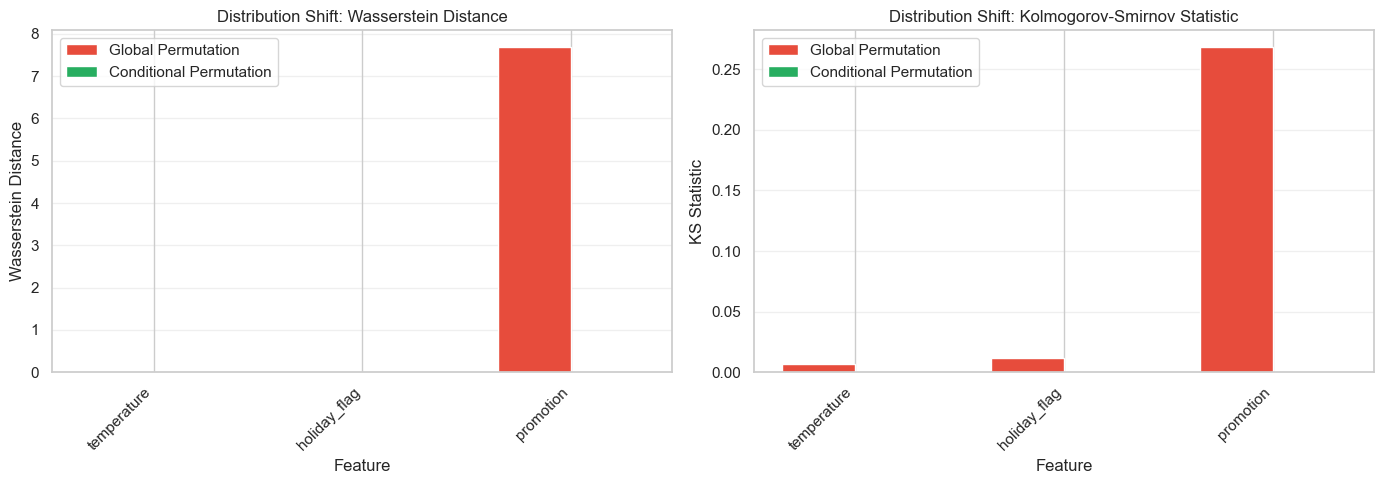

In [51]:
# Bar chart: Wasserstein distance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(exog_features))
width = 0.35

# Wasserstein Distance
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, ood_summary['wasserstein_global'], width, label='Global Permutation', color='#e74c3c')
bars2 = ax1.bar(x + width/2, ood_summary['wasserstein_conditional'], width, label='Conditional Permutation', color='#27ae60')
ax1.set_xlabel('Feature')
ax1.set_ylabel('Wasserstein Distance')
ax1.set_title('Distribution Shift: Wasserstein Distance')
ax1.set_xticks(x)
ax1.set_xticklabels(exog_features, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# KS Statistic
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, ood_summary['ks_global'], width, label='Global Permutation', color='#e74c3c')
bars4 = ax2.bar(x + width/2, ood_summary['ks_conditional'], width, label='Conditional Permutation', color='#27ae60')
ax2.set_xlabel('Feature')
ax2.set_ylabel('KS Statistic')
ax2.set_title('Distribution Shift: Kolmogorov-Smirnov Statistic')
ax2.set_xticks(x)
ax2.set_xticklabels(exog_features, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_ood_distance_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_ood_distance_comparison.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved OOD distance comparison to {FIGURE_DIR}')
plt.show()

Saved per-series distribution overlay to C:\Workspace\Research\conditional_multi_series\outputs\figures


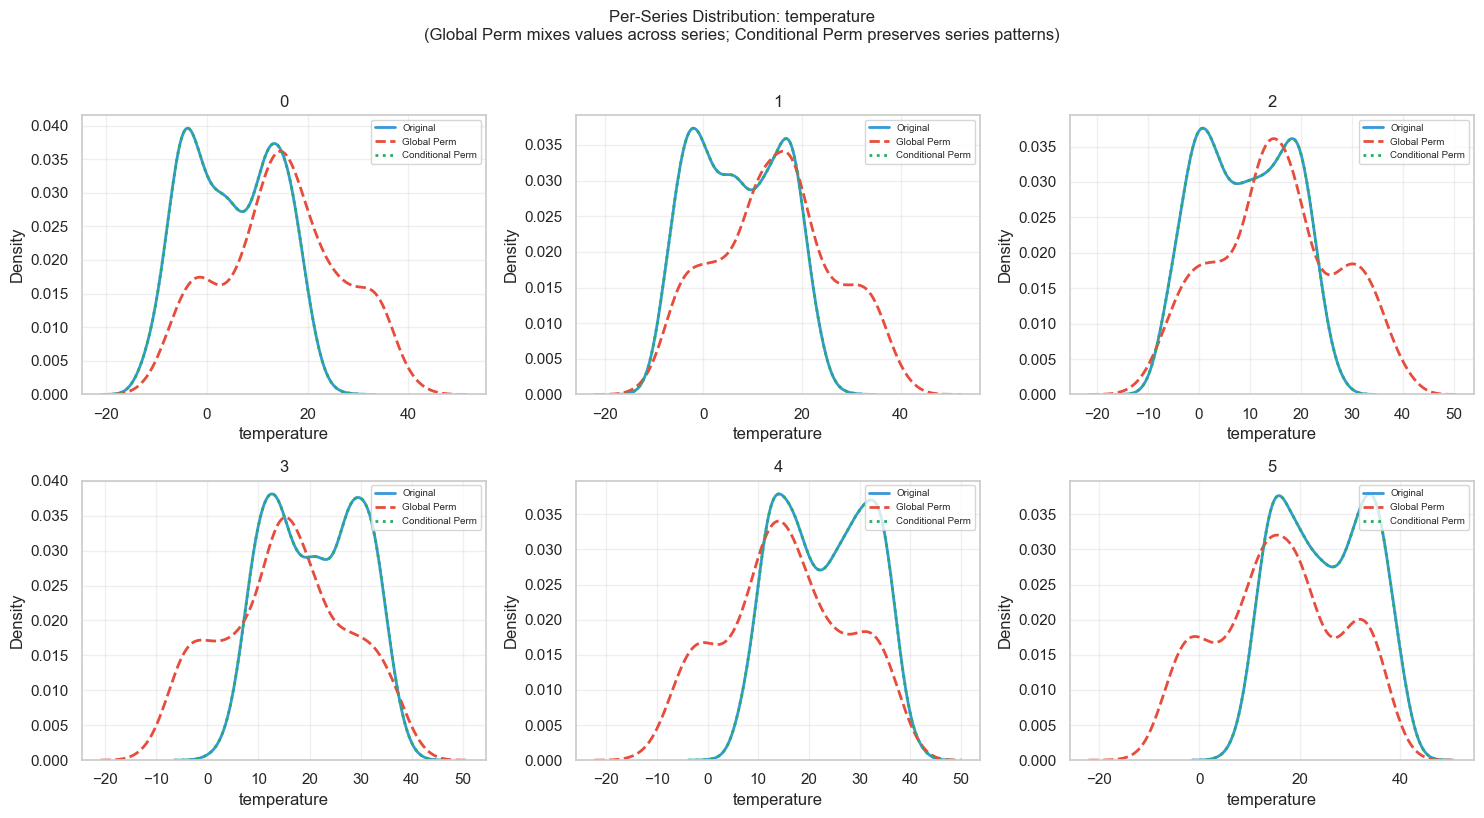

In [52]:
# Per-series KDE distribution for temperature (feature with heterogeneous distributions)
# This shows how global permutation destroys series-specific patterns
feat = 'temperature'
unique_series = sorted(X_train_sk[series_col].unique())
n_series = len(unique_series)
ncols = min(3, n_series)
nrows = (n_series + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n_series > 1 else [axes]

for idx, series_id in enumerate(unique_series):
    mask = X_train_sk[series_col] == series_id

    # Ordinal encoding uses alphabetical order, so use sorted series_ids
    alphabetical_series_ids = sorted(series_ids)
    series_name = alphabetical_series_ids[series_id] if isinstance(series_id, int) else str(series_id)
    
    ax = axes[idx]
    
    # Plot KDE for this series: original vs permuted
    orig_data = X_train_sk.loc[mask, feat].values
    global_data = X_global_perm.loc[mask, feat].values
    cond_data = X_cond_perm.loc[mask, feat].values
    
    sns.kdeplot(orig_data, ax=ax, label='Original', color='#3498db', linewidth=2)
    sns.kdeplot(global_data, ax=ax, label='Global Perm', color='#e74c3c', linewidth=2, linestyle='--')
    sns.kdeplot(cond_data, ax=ax, label='Conditional Perm', color='#27ae60', linewidth=2, linestyle=':')
    
    ax.set_title(f'{series_name}')
    ax.set_xlabel(f'{feat}')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    

# Hide unused subplots
for idx in range(n_series, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Per-Series Distribution: {feat}\n(Global Perm mixes values across series; Conditional Perm preserves series patterns)', 
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_ood_distribution_overlay.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_ood_distribution_overlay.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved per-series distribution overlay to {FIGURE_DIR}')
plt.show()

In [53]:
# Compute per-series MEAN SHIFT - this shows how permutation changes series-specific statistics
# Global permutation pulls all series toward the global mean; conditional preserves series means
mean_shift_records = []

for series_id in X_train_sk[series_col].unique():
    mask = X_train_sk[series_col] == series_id
    series_name = sorted(series_ids)[series_id] if isinstance(series_id, int) else str(series_id)
    
    for feat in exog_features:
        orig_mean = X_train_sk.loc[mask, feat].mean()
        orig_std = X_train_sk.loc[mask, feat].std()
        
        global_mean = X_global_perm.loc[mask, feat].mean()
        global_std = X_global_perm.loc[mask, feat].std()
        
        cond_mean = X_cond_perm.loc[mask, feat].mean()
        cond_std = X_cond_perm.loc[mask, feat].std()
        
        mean_shift_records.append({
            'series': series_name,
            'feature': feat,
            'original_mean': orig_mean,
            'global_mean_shift': abs(global_mean - orig_mean),
            'cond_mean_shift': abs(cond_mean - orig_mean),
            'global_std_shift': abs(global_std - orig_std),
            'cond_std_shift': abs(cond_std - orig_std),
        })

mean_shift_df = pd.DataFrame(mean_shift_records)
print('Per-series mean/std shift analysis:')
display(mean_shift_df)

Per-series mean/std shift analysis:


,series,feature,original_mean,global_mean_shift,cond_mean_shift,global_std_shift,cond_std_shift
0,3,temperature,21.127957,6.062447,0.000000e+00,3.270277,0.0
1,3,holiday_flag,0.137212,0.014270,0.000000e+00,0.014451,0.0
2,3,promotion,0.290889,0.010977,0.000000e+00,0.004896,0.0
3,4,temperature,23.086930,7.769518,0.000000e+00,3.285137,0.0
4,4,holiday_flag,0.146542,0.000549,0.000000e+00,0.000550,0.0
5,4,promotion,0.315038,0.017014,0.000000e+00,0.007143,0.0
6,5,temperature,24.982045,9.150738,0.000000e+00,3.351541,0.0
7,5,holiday_flag,0.156422,0.009330,0.000000e+00,0.009060,0.0
8,5,promotion,0.309550,0.008782,0.000000e+00,0.003717,0.0
9,0,temperature,4.992887,9.625531,0.000000e+00,3.008802,0.0


Saved mean shift heatmap to C:\Workspace\Research\conditional_multi_series\outputs\figures


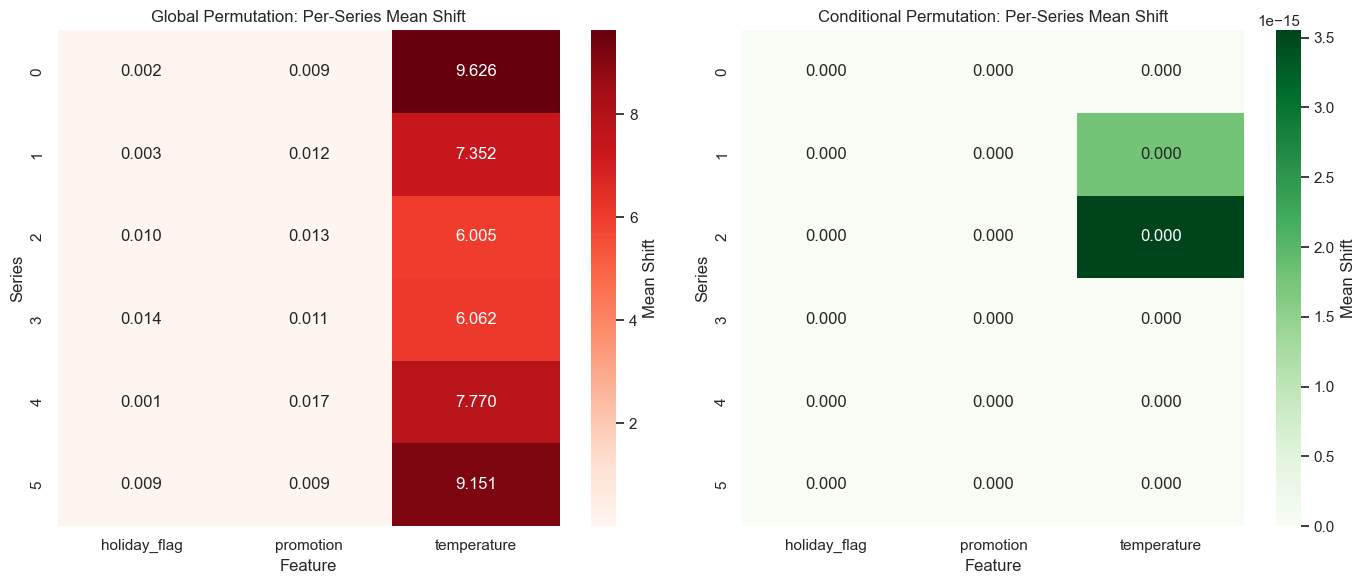

In [54]:
# Per-series heatmap of MEAN SHIFT - this is more informative than Wasserstein for showing
# how global permutation destroys series-specific patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global permutation mean shift
pivot_global = mean_shift_df.pivot(index='series', columns='feature', values='global_mean_shift')
sns.heatmap(pivot_global, annot=True, fmt='.3f', cmap='Reds', ax=axes[0], cbar_kws={'label': 'Mean Shift'})
axes[0].set_title('Global Permutation: Per-Series Mean Shift')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Series')

# Conditional permutation mean shift (should be ~0)
pivot_cond = mean_shift_df.pivot(index='series', columns='feature', values='cond_mean_shift')
sns.heatmap(pivot_cond, annot=True, fmt='.3f', cmap='Greens', ax=axes[1], cbar_kws={'label': 'Mean Shift'})
axes[1].set_title('Conditional Permutation: Per-Series Mean Shift')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Series')

plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_ood_mean_shift_heatmap.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_ood_mean_shift_heatmap.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved mean shift heatmap to {FIGURE_DIR}')
plt.show()

Saved statistics shift chart to C:\Workspace\Research\conditional_multi_series\outputs\figures


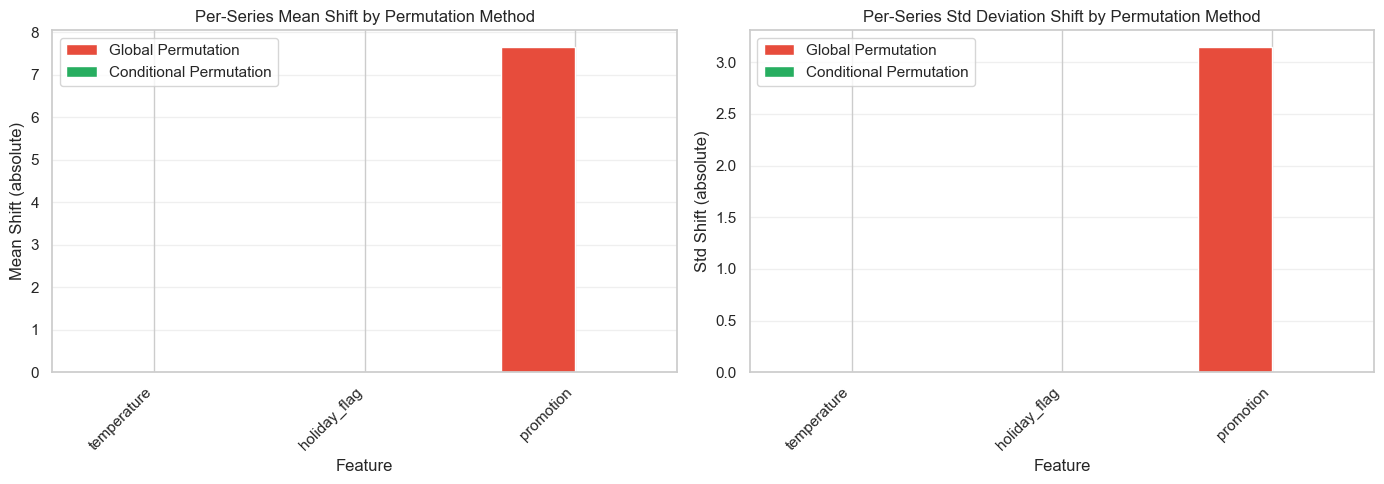


=== Mean Shift Summary ===
Global permutation average mean shift: 2.5597
Conditional permutation average mean shift: 0.000000

Key insight: Conditional permutation preserves per-series statistics (near-zero shift),
while global permutation significantly distorts series-specific patterns.


In [55]:
# Summary bar chart: Average mean shift across all series
mean_shift_summary = mean_shift_df.groupby('feature').agg({
    'global_mean_shift': 'mean',
    'cond_mean_shift': 'mean',
    'global_std_shift': 'mean',
    'cond_std_shift': 'mean',
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(exog_features))
width = 0.35

# Mean Shift
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, mean_shift_summary['global_mean_shift'], width, 
                label='Global Permutation', color='#e74c3c')
bars2 = ax1.bar(x + width/2, mean_shift_summary['cond_mean_shift'], width, 
                label='Conditional Permutation', color='#27ae60')
ax1.set_xlabel('Feature')
ax1.set_ylabel('Mean Shift (absolute)')
ax1.set_title('Per-Series Mean Shift by Permutation Method')
ax1.set_xticks(x)
ax1.set_xticklabels(exog_features, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Std Shift
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, mean_shift_summary['global_std_shift'], width, 
                label='Global Permutation', color='#e74c3c')
bars4 = ax2.bar(x + width/2, mean_shift_summary['cond_std_shift'], width, 
                label='Conditional Permutation', color='#27ae60')
ax2.set_xlabel('Feature')
ax2.set_ylabel('Std Shift (absolute)')
ax2.set_title('Per-Series Std Deviation Shift by Permutation Method')
ax2.set_xticks(x)
ax2.set_xticklabels(exog_features, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_ood_statistics_shift.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_ood_statistics_shift.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved statistics shift chart to {FIGURE_DIR}')
plt.show()

print('\n=== Mean Shift Summary ===')
print(f'Global permutation average mean shift: {mean_shift_summary["global_mean_shift"].mean():.4f}')
print(f'Conditional permutation average mean shift: {mean_shift_summary["cond_mean_shift"].mean():.6f}')
print(f'\nKey insight: Conditional permutation preserves per-series statistics (near-zero shift),')
print(f'while global permutation significantly distorts series-specific patterns.')

In [56]:
# Export all OOD analysis metrics
ood_df.to_csv(TABLE_DIR / '01_ood_distances.csv', index=False)
ood_summary.to_csv(TABLE_DIR / '01_ood_distances_summary.csv', index=False)
mean_shift_df.to_csv(TABLE_DIR / '01_ood_mean_shift.csv', index=False)
mean_shift_summary.to_csv(TABLE_DIR / '01_ood_mean_shift_summary.csv', index=False)

# LaTeX exports
latex_ood = ood_summary.to_latex(index=False, float_format='%.4f',
    caption='Out-of-distribution analysis: Wasserstein and KS distances.',
    label='tab:01_ood_distances')
with open(TABLE_DIR / '01_ood_distances.tex', 'w') as f:
    f.write(latex_ood)

latex_mean_shift = mean_shift_summary.to_latex(index=False, float_format='%.4f',
    caption='Per-series statistics shift: global vs conditional permutation.',
    label='tab:01_ood_mean_shift')
with open(TABLE_DIR / '01_ood_mean_shift.tex', 'w') as f:
    f.write(latex_mean_shift)

print(f'Saved OOD tables to {TABLE_DIR}')
print('\n' + '='*60)
print('OOD ANALYSIS SUMMARY')
print('='*60)
print(f'\nWasserstein Distance (averaged across features):')
print(f'  Global permutation:      {ood_summary["wasserstein_global"].mean():.4f}')
print(f'  Conditional permutation: {ood_summary["wasserstein_conditional"].mean():.6f}')
print(f'\nPer-Series Mean Shift (averaged across features):')
print(f'  Global permutation:      {mean_shift_summary["global_mean_shift"].mean():.4f}')
print(f'  Conditional permutation: {mean_shift_summary["cond_mean_shift"].mean():.6f}')
print(f'\nConclusion:')
print(f'  - Global permutation destroys series-specific patterns (high mean shift)')
print(f'  - Conditional permutation preserves per-series statistics (near-zero shift)')
print(f'  - This validates using conditional permutation for multi-series importance')
print('='*60)

Saved OOD tables to C:\Workspace\Research\conditional_multi_series\outputs\tables

OOD ANALYSIS SUMMARY

Wasserstein Distance (averaged across features):
  Global permutation:      2.5714
  Conditional permutation: 0.000000

Per-Series Mean Shift (averaged across features):
  Global permutation:      2.5597
  Conditional permutation: 0.000000

Conclusion:
  - Global permutation destroys series-specific patterns (high mean shift)
  - Conditional permutation preserves per-series statistics (near-zero shift)
  - This validates using conditional permutation for multi-series importance
